In [2]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Defining the methods as function to solve the given system problem

#explicit methods
def rk1(f, x0, y0, h, n, w, r):
    x = x0
    y = np.array(y0)
    x_values = [x0]
    y_values = [y.copy()]

    for i in range(n):
        y = y + h * f(x, y, w, r)
        x = x + h
        x_values.append(x)
        y_values.append(y.copy())

    return np.array(x_values), np.array(y_values)


def rk2(f, x0, y0, h, n, w, r):
    x = x0
    y = np.array(y0)
    x_values = [x0]
    y_values = [y.copy()]

    for i in range(n):
        k1 = f(x,y, w,r)
        k2  = f(x + h, y + h * k1)
        y = y + ((h/2) * (k1 + k2))
        x = x + h
        x_values.append(x)
        y_values.append(y.copy())

    return np.array(x_values), np.array(y_values)


def rk4(f, x0, y0, h, n, w, r):
    x = x0
    y = np.array(y0)
    x_values = [x0]
    y_values = [y.copy()]

    for i in range(n):
        k1 = f(x, y, w, r)
        k2 = f(x + h/2, y + (h/2)*k1, w, r)
        k3 = f(x + h/2, y + (h/2)*k2, w, r)
        k4 = f(x + h, y + h*k3, w, r)
        y = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x = x + h
        x_values.append(x)
        y_values.append(y.copy())

    return np.array(x_values), np.array(y_values)




#implicit methods

#backward euler method
def backward_euler_method(f, x0, y0, h, n, w, r):
    M = np.array([[0,1],
        [-w**2, -r]])
    I = np.eye(2)
    inv_mat = np.linalg.inv(I - h*M)

    x = x0
    y = np.array(y0)
    x_values = [x0]
    y_values = [y.copy()]

    for i in range(n):
        y = inv_mat @ y
        x = x + h

        x_values.append(x)
        y_values.append(y.copy())

    return np.array(x_values), np.array(y_values)

#Cranck-Nicolson Method
def crank_nicolson_method(f, x0, y0, h, n, w, r):
  x = x0
  y = np.array(y0)
  x_values = [x0]
  y_values = [y.copy()]

  M = np.array([[0,1],
        [-w**2, -r]])
  I = np.eye(2)
  mat1 = np.linalg.inv(I - (h/2)*M)
  mat2 = I + (h/2)*M

  for i in range(n):
      y = mat1 @ (mat2 @ y)
      x = x+h
      x_values.append(x)
      y_values.append(y.copy())

  return np.array(x_values), np.array(y_values)



#adoms bashforth method
def adams_bashforth_4(f, x0, y0, h, n):
    #Generate first 3 steps using RK4
    x_values, y_values = rk4(f, x0, y0, h, 3)
    #AB4 main loop
    for i in range(3, n):
        f_n  = f(x_values[i],   y_values[i])
        f_n1 = f(x_values[i-1], y_values[i-1])
        f_n2 = f(x_values[i-2], y_values[i-2])
        f_n3 = f(x_values[i-3], y_values[i-3])
        y_next = y_values[i] + (h/24)*(55*f_n - 59*f_n1 + 37*f_n2 - 9*f_n3)
        x_next = x_values[i] + h

        x_values = np.append(x_values, x_next)
        y_values = np.vstack([y_values, y_next])

    return x_values, y_values


#adams prdictor corrector method
def adams_predictor_corrector_4(f, x0, y0, h, n):

    #RK4 initialization
    x_values, y_values = rk4(f, x0, y0, h, 3)

    #Predictor–Corrector loop
    for i in range(3, n):
        f_n  = f(x_values[i],   y_values[i])
        f_n1 = f(x_values[i-1], y_values[i-1])
        f_n2 = f(x_values[i-2], y_values[i-2])
        f_n3 = f(x_values[i-3], y_values[i-3])
        #Predictor (AB4)
        y_pred = y_values[i] + (h/24)*(55*f_n - 59*f_n1 + 37*f_n2 - 9*f_n3)
        x_next = x_values[i] + h
        #Corrector (AM4)
        f_pred = f(x_next, y_pred)
        y_next = y_values[i] + (h/24)*(9*f_pred + 19*f_n - 5*f_n1 + f_n2)

        x_values = np.append(x_values, x_next)
        y_values = np.vstack([y_values, y_next])

    return x_values, y_values

In [4]:
#Initial Parameters
t0 = 0
x0 = 1
v0 = 0
w = 1
r = 20
tf = 10 #final time
y0 = np.array([x0, v0])

## System


In [5]:
#the ODE function
def f(t, y, w,r):
    x = y[0]    #position
    v = y[1]    #velocity
    dv = -r*v - (w**2)*x

    return np.array([v, dv]) #velocity, accelaration

#Task - 1: The explicit schemes

In [6]:
#Taking three different timesteps values
time_steps = [0.01, 0.07, 0.2]
n_values = []

for h in time_steps:
    n = int(np.ceil((tf - t0) / h))
    n_values.append(n)

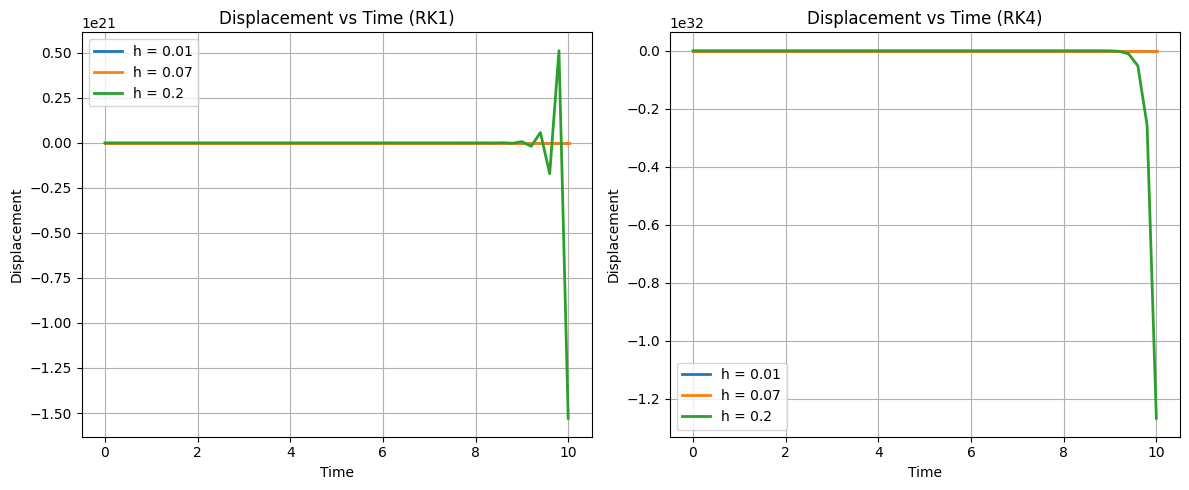

In [7]:
#displace plots
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#RK1
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk1(f, t0, y0, h, n, w, r)
    x_vals = y_vals[:, 0]
    ax[0].plot(t_vals, x_vals, linewidth=2, label=f"h = {h}")

ax[0].set_title("Displacement vs Time (RK1)", fontsize=12)
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Displacement")
ax[0].legend()
ax[0].grid()


#RK4
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk4(f, t0, y0, h, n, w, r)
    x_vals = y_vals[:, 0]
    ax[1].plot(t_vals, x_vals, linewidth=2, label=f"h = {h}")

ax[1].set_title("Displacement vs Time (RK4)", fontsize=12)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Displacement")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

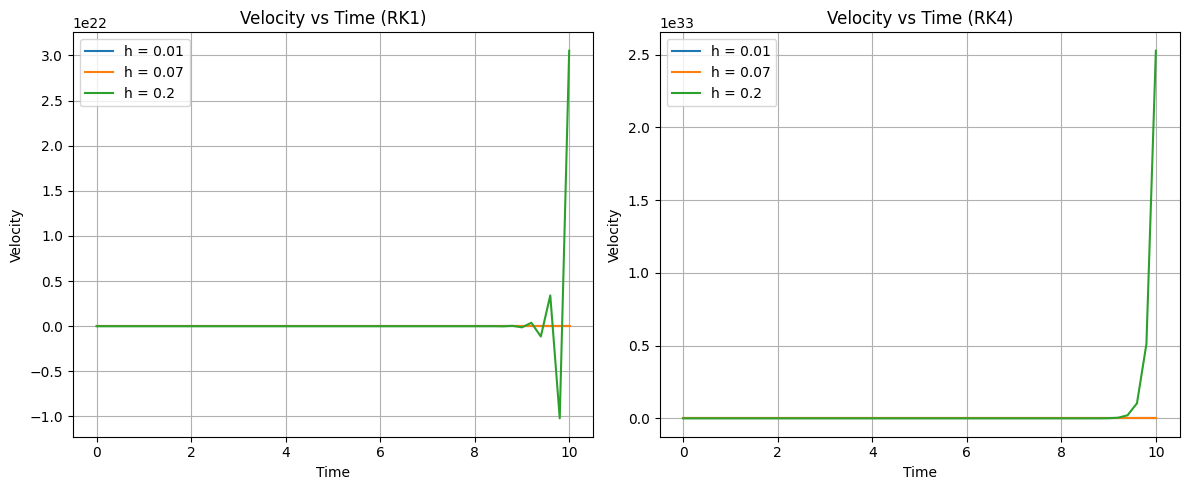

In [8]:
#velocity plots
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#RK1
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk1(f, t0, y0, h, n, w, r)
    v_vals = y_vals[:, 1]
    ax[0].plot(t_vals, v_vals, label=f"h = {h}")

ax[0].set_title("Velocity vs Time (RK1)")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Velocity")
ax[0].legend()
ax[0].grid()


#RK4
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk4(f, t0, y0, h, n, w, r)
    v_vals = y_vals[:, 1]
    ax[1].plot(t_vals, v_vals, label=f"h = {h}")

ax[1].set_title("Velocity vs Time (RK4)")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Velocity")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

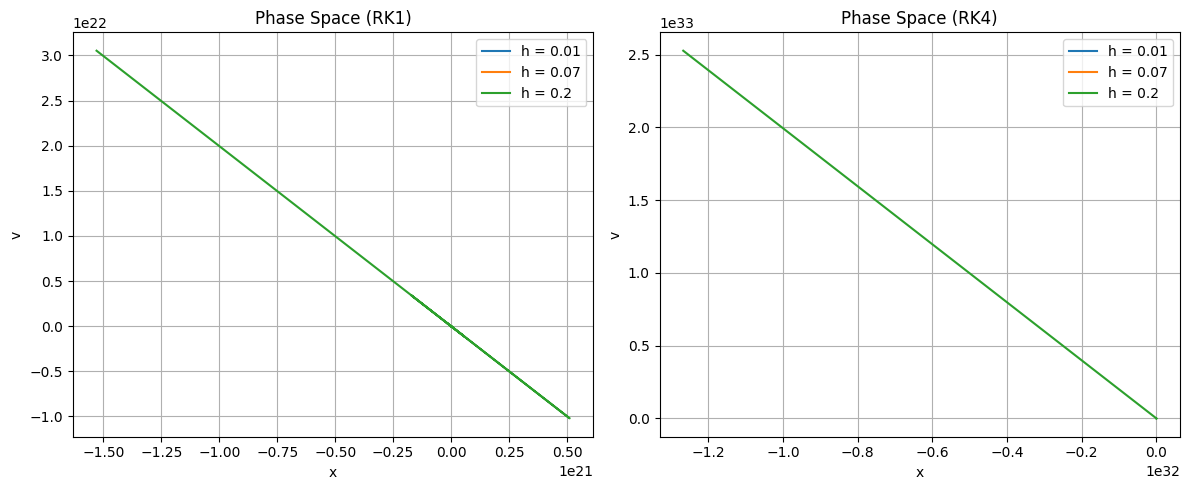

In [9]:
#phase space plots
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#RK1
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk1(f, t0, y0, h, n, w, r)
    ax[0].plot(y_vals[:,0], y_vals[:,1], label=f"h = {h}")

ax[0].set_title("Phase Space (RK1)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("v")
ax[0].legend()
ax[0].grid()

#RK4
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk4(f, t0, y0, h, n, w, r)
    ax[1].plot(y_vals[:,0], y_vals[:,1], label=f"h = {h}")

ax[1].set_title("Phase Space (RK4)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("v")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

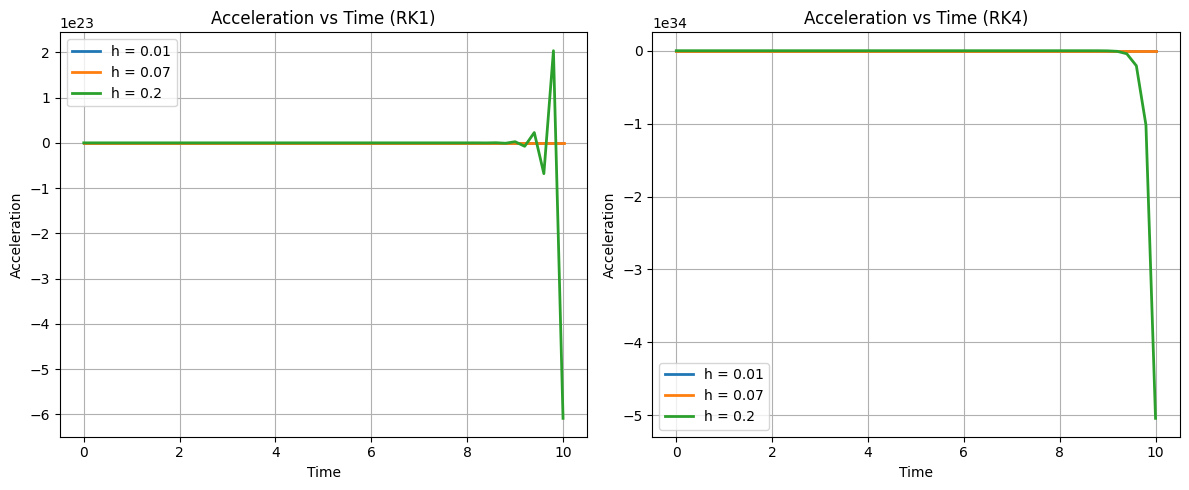

In [10]:
#accelaration graphs
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#RK1
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk1(f, t0, y0, h, n, w, r)

    acc_vals = np.zeros((len(t_vals)))
    for i in range(len(t_vals)):
        v, acc_vals[i] = f(t_vals[i], y_vals[i], w, r)
    ax[0].plot(t_vals, acc_vals, linewidth=2, label=f"h = {h}")
ax[0].set_title("Acceleration vs Time (RK1)")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Acceleration")
ax[0].legend()
ax[0].grid()

#RK4
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = rk4(f, t0, y0, h, n, w, r)

    acc_vals = np.zeros((len(t_vals)))
    for i in range(len(t_vals)):
        v, acc_vals[i] = f(t_vals[i], y_vals[i], w, r)
    ax[1].plot(t_vals, acc_vals, linewidth=2, label=f"h = {h}")

ax[1].set_title("Acceleration vs Time (RK4)")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Acceleration")
ax[1].legend()
ax[1].grid()


plt.tight_layout()
plt.show()

#Task - 2: Stability of explicit methods

In [11]:
#matrix for eigenvalue calculation
M = np.array([[0,1],
        [-w**2, -r]])
eig_vals = np.linalg.eigvals(M)

time_scale_1 = 1 / np.max(np.abs(eig_vals)) #fast mode
time_scale_2 = 1 / np.min(np.abs(eig_vals)) #slow mode
print(time_scale_1, time_scale_2)

0.050125628933800445 19.94987437106686


# Task - 3: Implement of implicit method

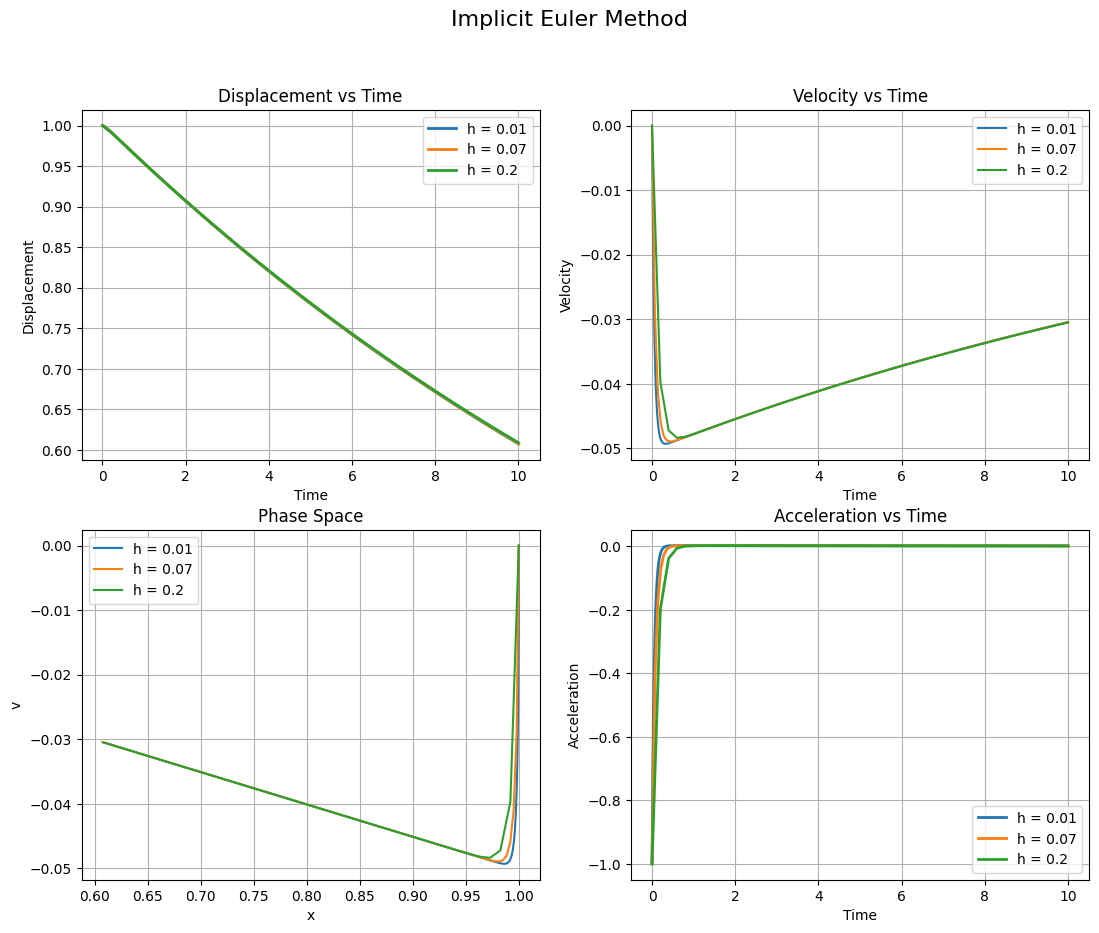

In [12]:
#Implicit Euler Method

fig, ax = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Implicit Euler Method', fontsize=16)

#displace plots
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = backward_euler_method(f, t0, y0, h, n, w, r)
    x_vals = y_vals[:, 0]
    ax[0,0].plot(t_vals, x_vals, linewidth=2, label=f"h = {h}")

ax[0,0].set_title("Displacement vs Time", fontsize=12)
ax[0,0].set_xlabel("Time")
ax[0,0].set_ylabel("Displacement")
ax[0,0].legend()
ax[0,0].grid()

#velocity plots
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = backward_euler_method(f, t0, y0, h, n, w,r)
    v_vals = y_vals[:, 1]
    ax[0,1].plot(t_vals, v_vals, label=f"h = {h}")

ax[0,1].set_title("Velocity vs Time")
ax[0,1].set_xlabel("Time")
ax[0,1].set_ylabel("Velocity")
ax[0,1].legend()
ax[0,1].grid()

#phase space plots
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = backward_euler_method(f, t0, y0, h, n, w, r)
    ax[1,0].plot(y_vals[:,0], y_vals[:,1], label=f"h = {h}")

ax[1,0].set_title("Phase Space")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("v")
ax[1,0].legend()
ax[1,0].grid()

#accelaration graphs
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = backward_euler_method(f, t0, y0, h, n, w, r)

    acc_vals = np.zeros((len(t_vals)))
    for i in range(len(t_vals)):
        v, acc_vals[i] = f(t_vals[i], y_vals[i], w,r)
    ax[1,1].plot(t_vals, acc_vals, linewidth=2, label=f"h = {h}")
ax[1,1].set_title("Acceleration vs Time")
ax[1,1].set_xlabel("Time")
ax[1,1].set_ylabel("Acceleration")
ax[1,1].legend()
ax[1,1].grid()

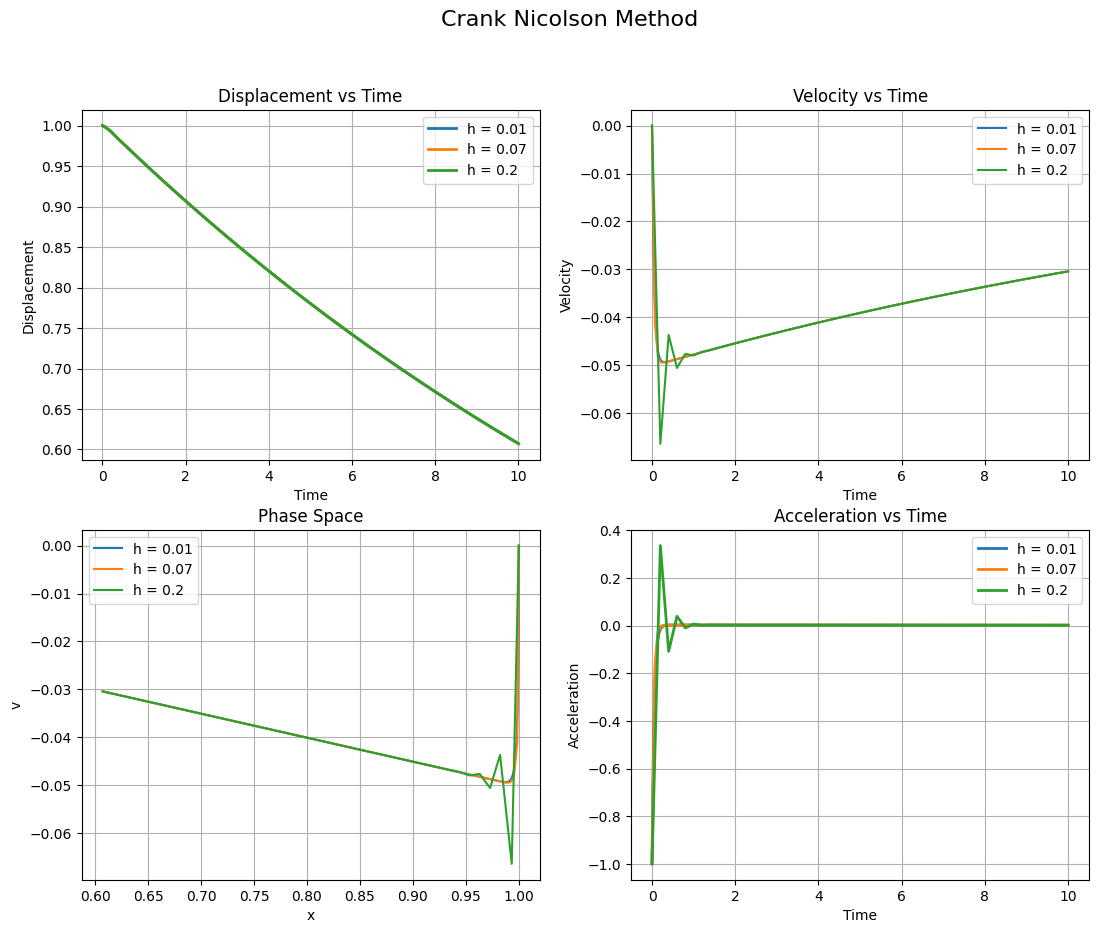

In [13]:
#Crank Nicolson Method

fig, ax = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Crank Nicolson Method', fontsize=16)

#displace plots
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = crank_nicolson_method(f, t0, y0, h, n, w, r)
    x_vals = y_vals[:, 0]
    ax[0,0].plot(t_vals, x_vals, linewidth=2, label=f"h = {h}")

ax[0,0].set_title("Displacement vs Time", fontsize=12)
ax[0,0].set_xlabel("Time")
ax[0,0].set_ylabel("Displacement")
ax[0,0].legend()
ax[0,0].grid()


#velocity plots
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = crank_nicolson_method(f, t0, y0, h, n, w, r)
    v_vals = y_vals[:, 1]
    ax[0,1].plot(t_vals, v_vals, label=f"h = {h}")

ax[0,1].set_title("Velocity vs Time")
ax[0,1].set_xlabel("Time")
ax[0,1].set_ylabel("Velocity")
ax[0,1].legend()
ax[0,1].grid()



#phase space plots
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = crank_nicolson_method(f, t0, y0, h, n, w, r)
    ax[1,0].plot(y_vals[:,0], y_vals[:,1], label=f"h = {h}")

ax[1,0].set_title("Phase Space")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("v")
ax[1,0].legend()
ax[1,0].grid()



#accelaration graphs
for h, n in zip(time_steps, n_values):
    t_vals, y_vals = crank_nicolson_method(f, t0, y0, h, n, w, r)

    acc_vals = np.zeros((len(t_vals)))
    for i in range(len(t_vals)):
        v, acc_vals[i] = f(t_vals[i], y_vals[i], w, r)
    ax[1,1].plot(t_vals, acc_vals, linewidth=2, label=f"h = {h}")
ax[1,1].set_title("Acceleration vs Time")
ax[1,1].set_xlabel("Time")
ax[1,1].set_ylabel("Acceleration")
ax[1,1].legend()
ax[1,1].grid()

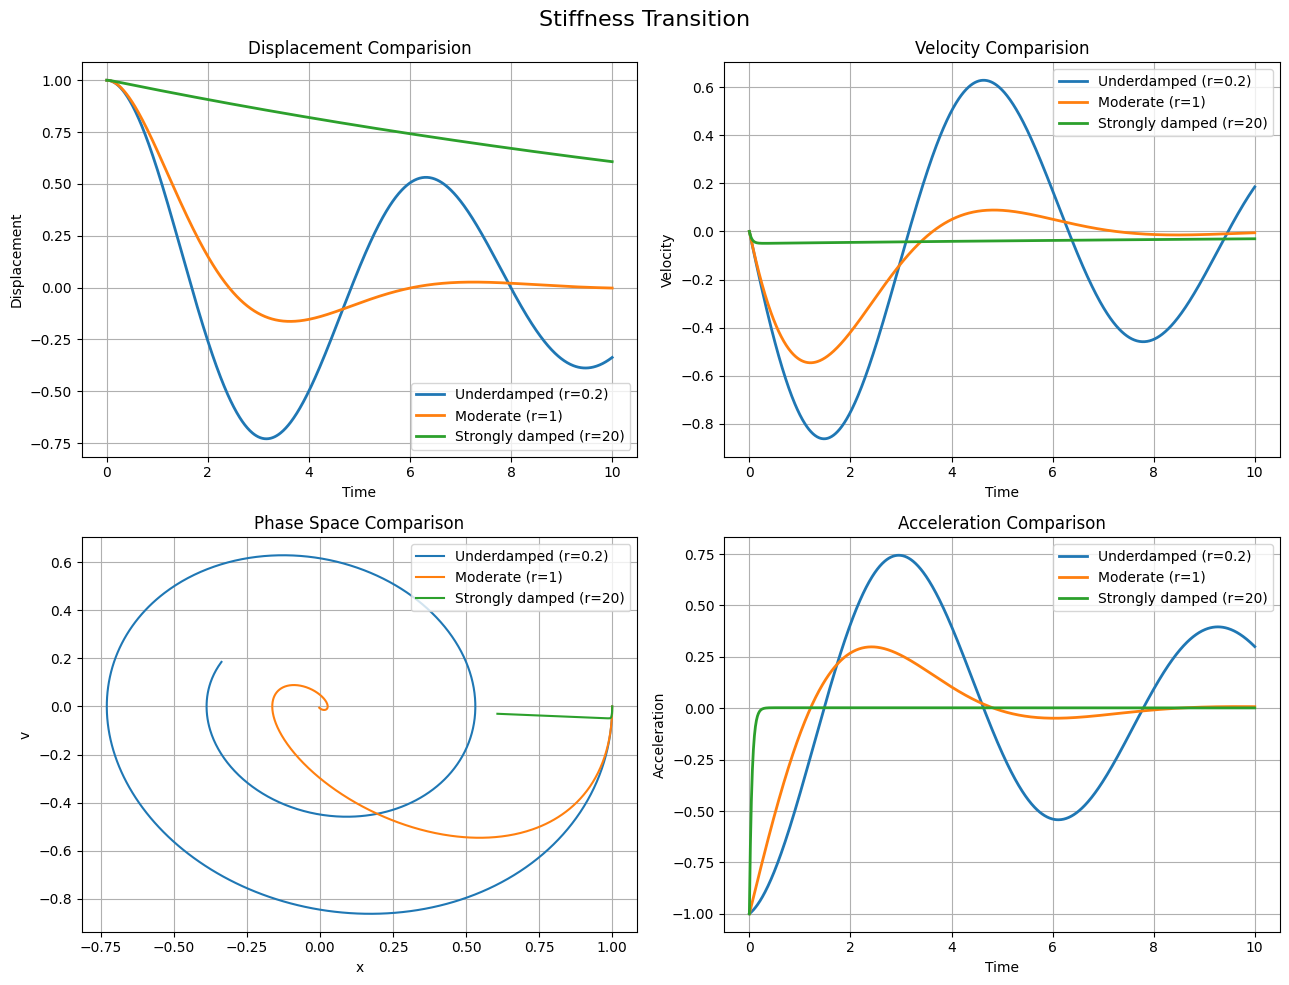

In [14]:
#Stiffness transition study

r_values = [0.2, 1, 20]   # underdamped, moderate, stiff

fig, ax = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Stiffness Transition', fontsize=16)

h = 0.01
n = int(np.ceil((tf - t0) / h))

for r in r_values:

    #redefine ODE with current r
    def f_local(t, y, w, r):
        x = y[0]
        v = y[1]
        return np.array([v, -r*v - (w**2)*x])

    t_vals, y_vals = rk4(f_local, t0, y0, h, n, w, r)

    acc_vals = np.zeros((len(t_vals)))
    for i in range(len(t_vals)):
        v, acc_vals[i] = f_local(t_vals[i], y_vals[i], w, r)

    if r == 0.2:
        label = "Underdamped (r=0.2)"
    elif r == 1:
        label = "Moderate (r=1)"
    else:
        label = "Strongly damped (r=20)"

    ax[0,0].plot(t_vals, y_vals[:,0], linewidth=2, label=label)
    ax[0,1].plot(t_vals, y_vals[:, 1], linewidth=2, label=label)
    ax[1,0].plot(y_vals[:,0], y_vals[:,1],label=label)
    ax[1,1].plot(t_vals, acc_vals, linewidth=2, label=label)

ax[0,0].set_title("Displacement Comparision", fontsize=12)
ax[0,0].set_xlabel("Time")
ax[0,0].set_ylabel("Displacement")
ax[0,0].legend()
ax[0,0].grid()

ax[0,1].set_title("Velocity Comparision")
ax[0,1].set_xlabel("Time")
ax[0,1].set_ylabel("Velocity")
ax[0,1].legend()
ax[0,1].grid()

ax[1,0].set_title("Phase Space Comparison")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("v")
ax[1,0].legend()
ax[1,0].grid()

ax[1,1].set_title("Acceleration Comparison")
ax[1,1].set_xlabel("Time")
ax[1,1].set_ylabel("Acceleration")
ax[1,1].legend()
ax[1,1].grid()

plt.tight_layout()
plt.show()